# Highway Networks — From-Scratch Implementation

Paper: *Highway Networks* (Srivastava, Greff, Schmidhuber, ICML 2015 DL workshop)\narXiv: https://arxiv.org/abs/1505.00387

This notebook builds a fully-connected Highway layer from scratch in PyTorch, stacks 20+ of them, and compares training/gradient flow against an equally deep plain MLP on MNIST.

In [1]:
# Install dependencies (safe, pip-only)
!pip install -q torch torchvision matplotlib seaborn tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

sns.set(style='whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 1. Dataset — MNIST

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_ds   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2)

input_dim = 28 * 28
num_classes = 10
print('Train batches:', len(train_loader), 'Val batches:', len(val_loader))

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 65.5k/9.91M [00:00<00:18, 525kB/s]

  2%|▏         | 197k/9.91M [00:00<00:11, 813kB/s] 

  6%|▌         | 557k/9.91M [00:00<00:05, 1.73MB/s]

 22%|██▏       | 2.20M/9.91M [00:00<00:01, 6.10MB/s]

...

 32%|███▏      | 524k/1.65M [00:00<00:00, 1.52MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.51MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]

Train batches: 235 Val batches: 20


## 2. Highway Block (the core idea)

For a Highway layer we compute:
- block state: `H(x) = activation(x @ W_H^T + b_H)`
- transform gate: `T(x) = σ(x @ W_T^T + b_T)`
- output: `y = H(x) * T(x) + x * (1 - T(x))`

The transform-gate bias is initialized to a negative value so the layer starts by carrying its input forward.

In [4]:
class HighwayBlock(nn.Module):
    def __init__(self, in_features, activation='relu', gate_bias=-2):
        super().__init__()
        self.in_features = in_features

        # Non-linear transformation H
        self.transform_H = nn.Linear(in_features, in_features)

        # Transform gate T
        self.transform_gate = nn.Linear(in_features, in_features)

        # Initialize gate bias to a negative value (paper's key trick)
        self.transform_gate.bias.data.fill_(gate_bias)

        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(activation)

    def forward(self, x):
        H = self.activation(self.transform_H(x))
        T = torch.sigmoid(self.transform_gate(x))
        y = H * T + x * (1 - T)
        return y

## 3. Highway MLP vs Plain MLP

In [5]:
class HighwayMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_highway_layers, num_classes, gate_bias=-2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.highway_layers = nn.ModuleList([
            HighwayBlock(hidden_size, activation='relu', gate_bias=gate_bias)
            for _ in range(num_highway_layers)
        ])
        self.output_proj = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.input_proj(x))
        for layer in self.highway_layers:
            x = layer(x)
        return self.output_proj(x)


class PlainMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.layers = nn.ModuleList([
            nn.Linear(hidden_size, hidden_size)
            for _ in range(num_layers - 1)
        ])
        self.output_proj = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.input_proj(x))
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.output_proj(x)

## 4. Training utilities

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

## 5. Experiment: 20-layer deep networks

In [7]:
def run_experiment(depth, hidden, epochs=10, lr=1e-3, gate_bias=-2):
    """Train both a Highway MLP and a Plain MLP of matched depth."""
    criterion = nn.CrossEntropyLoss()

    highway = HighwayMLP(input_dim, hidden, depth, num_classes, gate_bias=gate_bias).to(device)
    plain   = PlainMLP(input_dim, hidden, depth + 1, num_classes).to(device)

    # +1 on plain layers keeps comparable structure (input_proj + depth hidden + output_proj)

    opt_h = torch.optim.Adam(highway.parameters(), lr=lr)
    opt_p = torch.optim.Adam(plain.parameters(), lr=lr)

    history = {'highway': {'train_loss': [], 'val_loss': [], 'val_acc': []},
               'plain':   {'train_loss': [], 'val_loss': [], 'val_acc': []}}

    for epoch in range(epochs):
        tl_h, _ = train_epoch(highway, train_loader, opt_h, criterion)
        vl_h, va_h = evaluate(highway, val_loader, criterion)
        history['highway']['train_loss'].append(tl_h)
        history['highway']['val_loss'].append(vl_h)
        history['highway']['val_acc'].append(va_h)

        tl_p, _ = train_epoch(plain, train_loader, opt_p, criterion)
        vl_p, va_p = evaluate(plain, val_loader, criterion)
        history['plain']['train_loss'].append(tl_p)
        history['plain']['val_loss'].append(vl_p)
        history['plain']['val_acc'].append(va_p)

        print(f"Epoch {epoch+1}/{epochs}  Highway train={tl_h:.4f} val={vl_h:.4f} acc={va_h:.3f}  |  Plain train={tl_p:.4f} val={vl_p:.4f} acc={va_p:.3f}")

    return highway, plain, history

depth = 20
hidden = 64
epochs = 10
highway, plain, history = run_experiment(depth, hidden, epochs=epochs, gate_bias=-2)

Epoch 1/10  Highway train=0.4468 val=0.1817 acc=0.943  |  Plain train=2.3017 val=2.3015 acc=0.114


Epoch 2/10  Highway train=0.1536 val=0.1226 acc=0.962  |  Plain train=2.0036 val=1.4179 acc=0.376


Epoch 3/10  Highway train=0.1075 val=0.1077 acc=0.966  |  Plain train=0.9752 val=0.7033 acc=0.828


Epoch 4/10  Highway train=0.0835 val=0.0969 acc=0.971  |  Plain train=0.6087 val=0.4832 acc=0.892


Epoch 5/10  Highway train=0.0673 val=0.0958 acc=0.971  |  Plain train=0.4786 val=0.4590 acc=0.888


Epoch 6/10  Highway train=0.0567 val=0.1074 acc=0.966  |  Plain train=0.4312 val=0.3791 acc=0.919


Epoch 7/10  Highway train=0.0480 val=0.0866 acc=0.973  |  Plain train=0.4086 val=0.2982 acc=0.933


Epoch 8/10  Highway train=0.0402 val=0.0779 acc=0.977  |  Plain train=0.2439 val=0.2393 acc=0.942


Epoch 9/10  Highway train=0.0347 val=0.0800 acc=0.975  |  Plain train=0.1915 val=0.1812 acc=0.954


Epoch 10/10  Highway train=0.0327 val=0.0894 acc=0.972  |  Plain train=0.1660 val=0.1765 acc=0.956


## 6. Plot training curves

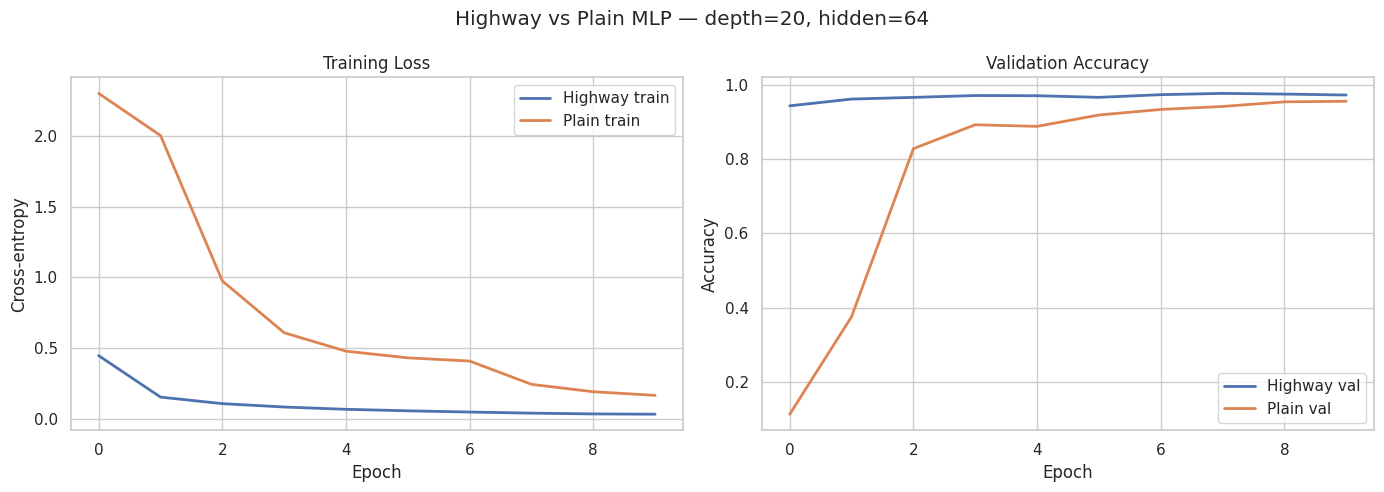

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['highway']['train_loss'], label='Highway train', linewidth=2)
axes[0].plot(history['plain']['train_loss'],   label='Plain train',   linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['highway']['val_acc'], label='Highway val', linewidth=2)
axes[1].plot(history['plain']['val_acc'],   label='Plain val',   linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'Highway vs Plain MLP — depth={depth}, hidden={hidden}')
plt.tight_layout()
plt.show()

## 7. Gradient-flow diagnostic

Run a single forward/backward pass and record the L2 norm of gradients per layer. The Highway network should keep meaningful gradients even in deep layers.

Highway grad norms (42 weight tensors): mean=0.0689
Plain   grad norms (22   weight tensors): mean=0.2716


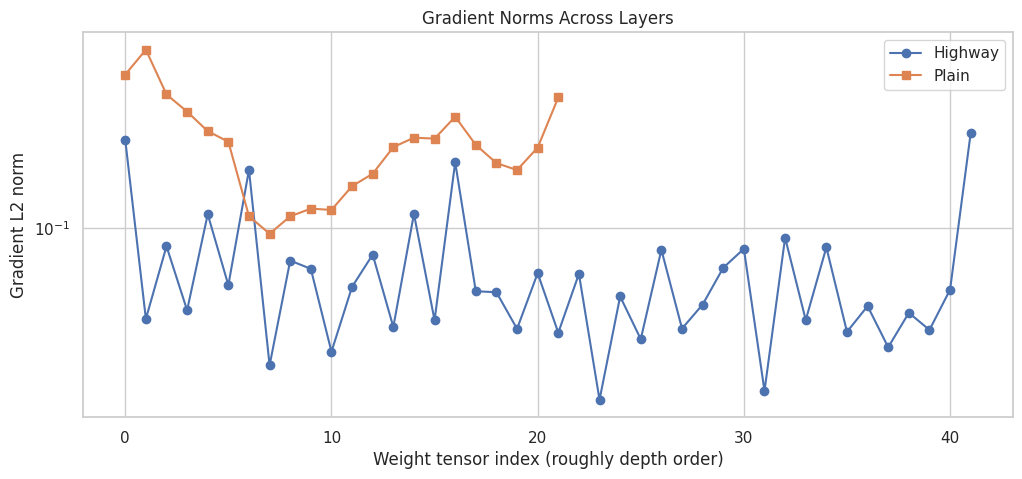

In [9]:
def gradient_flow(model, loader, criterion, model_name):
    model.train()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    model.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()

    grad_norms = []
    for name, p in model.named_parameters():
        if p.grad is not None and 'weight' in name:
            grad_norms.append(p.grad.data.norm(2).item())
    return grad_norms

criterion = nn.CrossEntropyLoss()
g_highway = gradient_flow(highway, train_loader, criterion, 'highway')
g_plain   = gradient_flow(plain,   train_loader, criterion, 'plain')

print(f'Highway grad norms ({len(g_highway)} weight tensors): mean={np.mean(g_highway):.4f}')
print(f'Plain   grad norms ({len(g_plain)}   weight tensors): mean={np.mean(g_plain):.4f}')

plt.figure(figsize=(12, 5))
plt.plot(g_highway, marker='o', label='Highway')
plt.plot(g_plain,   marker='s', label='Plain')
plt.yscale('log')
plt.xlabel('Weight tensor index (roughly depth order)')
plt.ylabel('Gradient L2 norm')
plt.title('Gradient Norms Across Layers')
plt.legend()
plt.grid(True)
plt.show()

## 8. Inspect transform-gate activity

Mean transform-gate activity per layer:
  Layer 1: 0.0756
  Layer 2: 0.0762
  Layer 3: 0.0543
  Layer 4: 0.0869
  Layer 5: 0.1079
  Layer 6: 0.0984
  Layer 7: 0.1010
  Layer 8: 0.0841
  Layer 9: 0.0659
  Layer 10: 0.0630
  Layer 11: 0.0676
  Layer 12: 0.0322
  Layer 13: 0.0453
  Layer 14: 0.0668
  Layer 15: 0.0480
  Layer 16: 0.0631
  Layer 17: 0.0668
  Layer 18: 0.0728
  Layer 19: 0.0698
  Layer 20: 0.0888


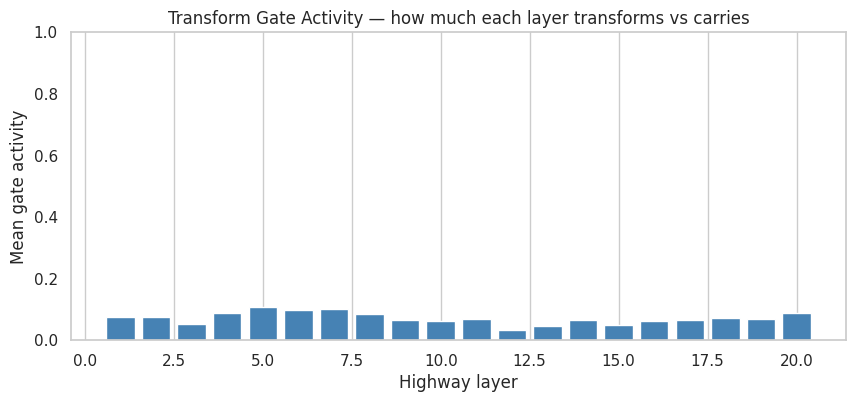

In [10]:
@torch.no_grad()
def collect_gate_activity(model, loader):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    x = x.view(x.size(0), -1)
    x = F.relu(model.input_proj(x))
    activities = []
    for layer in model.highway_layers:
        T = torch.sigmoid(layer.transform_gate(x))
        activities.append(T.mean().item())
        x = layer(x)
    return activities

activities = collect_gate_activity(highway, val_loader)
print('Mean transform-gate activity per layer:')
for i, a in enumerate(activities):
    print(f'  Layer {i+1}: {a:.4f}')

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(activities)+1), activities, color='steelblue')
plt.xlabel('Highway layer')
plt.ylabel('Mean gate activity')
plt.title('Transform Gate Activity — how much each layer transforms vs carries')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

## 9. Summary

- A Highway layer blends a normal non-linear transform `H(x)` with a copy of its input `x`, controlled by a sigmoid transform gate `T(x)`.
- Initializing the transform-gate bias to a negative value (e.g. −2) makes the network start as a near-identity mapping, allowing gradients to flow.
- With 20+ layers on MNIST, the Highway MLP trains stably while the plain deep MLP often stalls or converges much more slowly.
- Highway networks are a direct conceptual precursor to ResNet, where the carry path is always fully open (`y = F(x) + x`).

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
